In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/My\ Drive/ /mydrive
%cd /mydrive/Pytorch-Models

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
ln: failed to create symbolic link '/mydrive/My Drive': File exists
/content/gdrive/.shortcut-targets-by-id/1aJsbt04Jz9xcLP_lg7fvP4Bpdce6GQlC/Pytorch-Models


In [2]:
import os
import json

def count_images(image_dir, exts={".jpg", ".jpeg", ".png", ".bmp", ".webp"}):
    image_count = 0
    for filename in os.listdir(image_dir):
        if os.path.splitext(filename.lower())[1] in exts:
            image_count += 1
    print(f"Total images: {image_count}")

count_images("datasets/excavator/train")
count_images("datasets/excavator/valid")

Total images: 642
Total images: 54


In [ ]:
train_json = "datasets/excavator/train/_annotations.coco.json"
valid_json = "datasets/excavator/valid/_annotations.coco.json"

In [ ]:
from pycocotools.coco import COCO
import matplotlib.pyplot as plt
import cv2
import os
import math
import random

def visualize_coco_keypoints(json_path, img_dir, num_images=9):
    coco = COCO(json_path)
    img_ids = coco.getImgIds()
    random.shuffle(img_ids)
    num_images = min(num_images, len(img_ids))

    # Find category that has keypoints
    cats = coco.loadCats(coco.getCatIds())
    cat_with_kps = next((cat for cat in cats if 'keypoints' in cat and 'skeleton' in cat), None)

    if not cat_with_kps:
        print("No category with keypoints and skeleton found.")
        return

    keypoint_names = cat_with_kps['keypoints']
    skeleton = cat_with_kps['skeleton']

    cols = 3
    rows = math.ceil(num_images / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = axes.flatten()

    for idx in range(num_images):
        img_id = img_ids[idx]
        img_info = coco.loadImgs(img_id)[0]
        img_path = os.path.join(img_dir, img_info['file_name'])
        img = cv2.imread(img_path)
        if img is None:
            print(f"Image not found: {img_path}")
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ann_ids = coco.getAnnIds(imgIds=img_info['id'])
        anns = coco.loadAnns(ann_ids)

        ax = axes[idx]
        ax.imshow(img)

        for ann in anns:
            if 'keypoints' not in ann:
                continue

            kps = ann['keypoints']
            keypoints_xyv = [(kps[i], kps[i+1], kps[i+2]) for i in range(0, len(kps), 3)]

            # Plot skeleton lines
            for pair in skeleton:
                idx1, idx2 = pair[0] - 1, pair[1] - 1  # 1-based to 0-based
                if idx1 < len(keypoints_xyv) and idx2 < len(keypoints_xyv):
                    x1, y1, v1 = keypoints_xyv[idx1]
                    x2, y2, v2 = keypoints_xyv[idx2]
                    if v1 > 0 and v2 > 0:
                        ax.plot([x1, x2], [y1, y2], 'cyan', linewidth=2)

            # Plot keypoints
            for i, (x, y, v) in enumerate(keypoints_xyv):
                if v > 0:
                    ax.plot(x, y, 'ro' if v == 2 else 'go', markersize=5)
                    ax.text(x + 5, y - 5, keypoint_names[i],
                            fontsize=8,
                            color='yellow',
                            ha='left', va='bottom')

        ax.set_title(img_info['file_name'], fontsize=10)
        ax.axis('off')

    for j in range(num_images, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


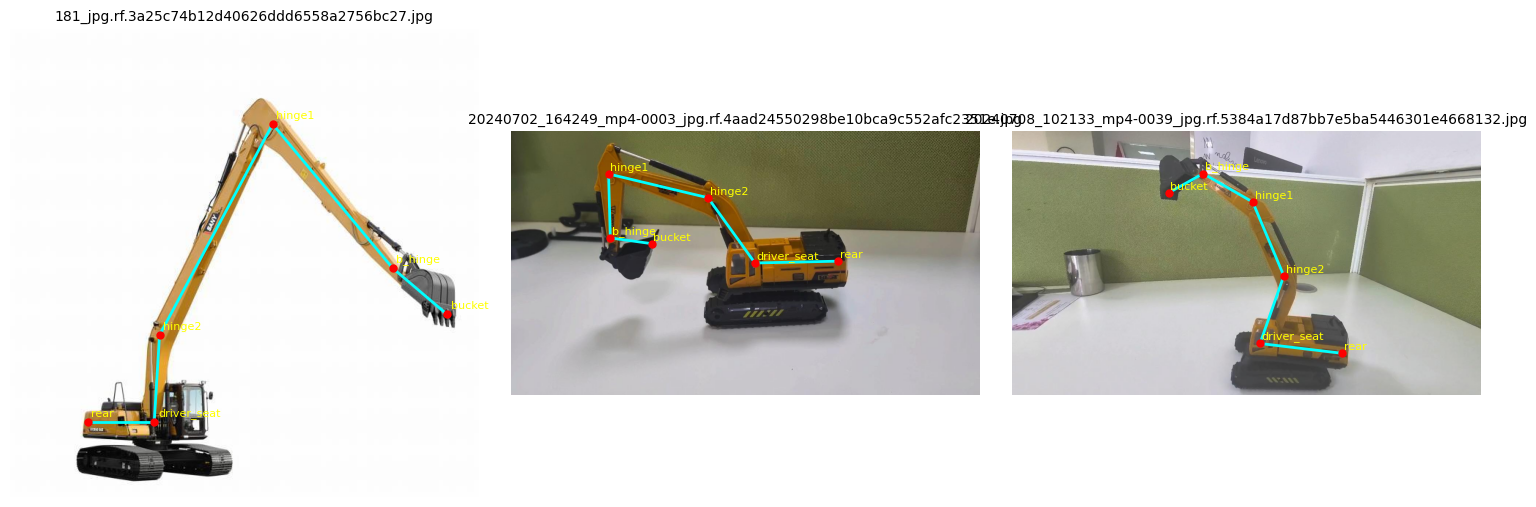

In [ ]:
visualize_coco_keypoints(train_json, "datasets/excavator/train", num_images=3)

In [ ]:
# STEP 1: Install PyTorch
!pip install torch==2.0.1 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu117

# STEP 2: Install OpenMMLab Core
!pip install -U openmim
!mim install "mmengine>=0.7.4"
!mim install "mmcv==2.0.1"
!mim install "mmdet==3.1.0"  # Needed if using detection-based models

In [ ]:
# STEP 3: Install MMPose
!git clone https://github.com/open-mmlab/mmpose.git
%cd mmpose
!pip install -e .

In [ ]:
!git clone https://github.com/open-mmlab/mmdeploy.git
%cd mmdeploy
!pip install -e .

In [2]:
!python -c "import mmdeploy; print('MMDeploy:', mmdeploy.__version__)"

MMDeploy: 1.3.1


In [ ]:
!pip install numpy==1.25.2 scipy==1.11.4 --force-reinstall

In [2]:
%cd mmpose

/content/gdrive/.shortcut-targets-by-id/1aJsbt04Jz9xcLP_lg7fvP4Bpdce6GQlC/Pytorch-Models/mmpose


In [3]:
import torch
import mmcv
import mmengine
import mmdet
import mmpose

print("Torch:", torch.__version__)
print("MMCV:", mmcv.__version__)
print("MMEngine:", mmengine.__version__)
print("MMDetection:", mmdet.__version__)
print("MMPose:", mmpose.__version__)

Torch: 2.0.1+cu117
MMCV: 2.0.1
MMEngine: 0.10.7
MMDetection: 3.1.0
MMPose: 1.3.2


In [4]:
!ls /content/gdrive/MyDrive/Pytorch-Models/mmpose/configs/body_2d_keypoint/dekr/coco/

dekr_excavator.py			   hrnet_coco.md
dekr_hrnet-w32_8xb10-140e_coco-512x512.py  hrnet_coco.yml
dekr_hrnet-w48_8xb10-140e_coco-640x640.py


Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/v1/body_2d_keypoint/dekr/coco/dekr_hrnet-w48_8xb10-140e_coco-640x640_74796c32-20230124.pth


/usr/local/lib/python3.11/dist-packages/torch/nn/functional.py:4236: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(


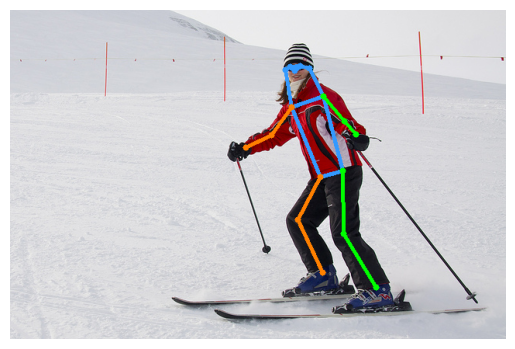

In [ ]:
from mmdet.apis import init_detector, inference_detector
from mmpose.apis import MMPoseInferencer
from mmengine.structures import InstanceData
import mmcv
import cv2
from IPython.display import Image, display
import matplotlib.pyplot as plt

# --- Paths ---
img = 'tests/data/coco/000000000785.jpg'

pose_config = '/content/gdrive/MyDrive/Pytorch-Models/mmpose/configs/body_2d_keypoint/dekr/coco/dekr_hrnet-w48_8xb10-140e_coco-640x640.py'
pose_checkpoint = 'https://download.openmmlab.com/mmpose/v1/body_2d_keypoint/dekr/coco/dekr_hrnet-w48_8xb10-140e_coco-640x640_74796c32-20230124.pth'

pose_inferencer = MMPoseInferencer(pose2d=pose_config, pose2d_weights=pose_checkpoint)

person_results = []

# --- Step 2: Run Pose Inference ---
results_gen = pose_inferencer(
    img,
    det_results=person_results,
    return_vis=True,
    show=False,
    radius=4,       # Adjusts keypoint (point) size (default: 3)
    thickness=3,    # Adjusts link (line) thickness (default: 1)
    kpt_thr=0.3     # Optional: Threshold to filter visible points (default: 0.3)
)

# --- Step 3: Show ---
for r in results_gen:
    vis_img = r['visualization'][0]
    plt.imshow(vis_img)
    plt.axis('off')
    plt.show()

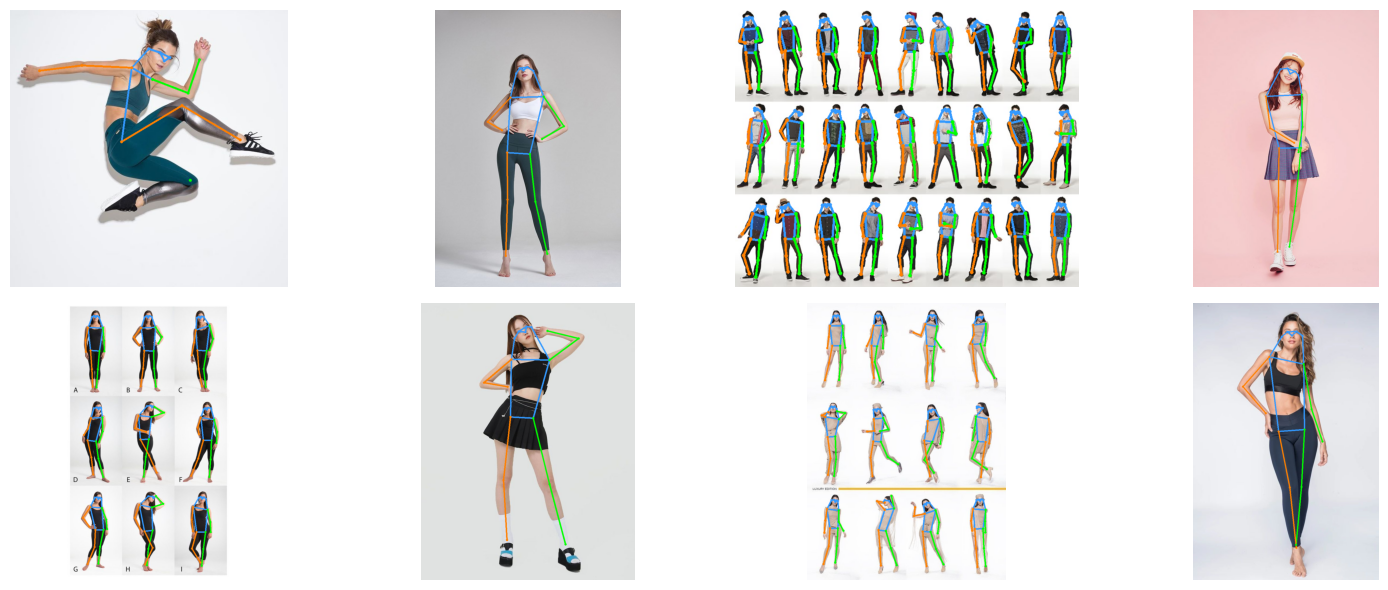

In [ ]:
# ---------------- CONFIG ----------------
val_dir = "/content/gdrive/MyDrive/Pytorch-Models/datasets/pose-tests/"

import os
import random
import numpy as np

# visualization layout
N = 8
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 3 * rows))

for ii, image in enumerate(sample_imgs):
    plt.subplot(2, 4, ii+1)

    results_gen = pose_inferencer(
        image,
        det_results=person_results,
        return_vis=True,
        show=False,
        radius=4,       # Adjusts keypoint (point) size (default: 3)
        thickness=3,    # Adjusts link (line) thickness (default: 1)
        kpt_thr=0.3     # Optional: Threshold to filter visible points (default: 0.3)
    )

    for r in results_gen:
        vis_img = r['visualization'][0]

    plt.subplot(rows, cols, ii + 1)
    plt.imshow(vis_img)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
custom_cfg = """
_base_ = ['dekr_hrnet-w48_8xb10-140e_coco-640x640.py']

dataset_type = 'CocoDataset'
data_root = '/content/gdrive/MyDrive/Pytorch-Models/datasets/excavator/'
data_mode = 'bottomup'

num_keypoints = 6
metainfo = {
    'dataset_name': 'excavator',
    'keypoint_info': {
        0: dict(name='bucket', id=0, color=[255, 0, 0], type='', swap=''),
        1: dict(name='hinge1', id=1, color=[0, 255, 0], type='', swap=''),
        2: dict(name='hinge2', id=2, color=[0, 0, 255], type='', swap=''),
        3: dict(name='driver_seat', id=3, color=[255, 255, 0], type='', swap=''),
        4: dict(name='rear', id=4, color=[255, 0, 255], type='', swap=''),
        5: dict(name='b_hinge', id=5, color=[0, 255, 255], type='', swap='')
    },
    'skeleton_info': {
        0: dict(link=('bucket', 'b_hinge'), id=0, color=[255, 128, 0]),
        1: dict(link=('hinge1', 'hinge2'), id=1, color=[128, 255, 0]),
        2: dict(link=('hinge2', 'driver_seat'), id=2, color=[0, 255, 128]),
        3: dict(link=('driver_seat', 'rear'), id=3, color=[0, 128, 255]),
        4: dict(link=('b_hinge', 'hinge1'), id=4, color=[128, 0, 255])
    },
    'joint_weights': [1.0] * 6,
    'sigmas': [0.026, 0.025, 0.025, 0.035, 0.035, 0.025],
    'dataset_keypoint_weights': [1.0] * 6,
    'dataset_channel': [[0, 1, 2, 3, 4, 5]],
    'flip_index': [0, 1, 2, 3, 4, 5],  # no left/right flip distinction
    'flip_indices': [0, 1, 2, 3, 4, 5],
    '_delete_': True
}

# data
input_size = (640, 640)
# codec settings
codec = dict(
    type='SPR',
    input_size=(640, 640),
    heatmap_size=(160, 160),
    sigma=(4, 2),
    minimal_diagonal_length=32**0.5,
    generate_keypoint_heatmaps=True,
    decode_max_instances=30)

# pipelines
train_pipeline = [
    dict(type='LoadImage'),
    dict(
        type='BottomupRandomAffine',
        input_size=codec['input_size'],
        scale_factor=(1.0, 1.2),
        rotate_factor=10,
        shift_factor = 0.0,
    ),
    dict(type='RandomFlip', direction='horizontal'),
    dict(type='GenerateTarget', encoder=codec),
    dict(type='BottomupGetHeatmapMask'),
    dict(type='PackPoseInputs'),
]

val_pipeline = [
    dict(type='LoadImage'),
    dict(
        type='BottomupResize',
        input_size=codec['input_size'],
        size_factor=32,
        resize_mode='expand'),
    dict(
        type='PackPoseInputs',
        meta_keys=('id', 'img_id', 'img_path', 'crowd_index', 'ori_shape',
                   'img_shape', 'input_size', 'input_center', 'input_scale',
                   'flip', 'flip_direction', 'flip_indices', 'raw_ann_info',
                   'skeleton_links'))
]

train_dataloader = dict(
    batch_size=8,
    num_workers=2,
    persistent_workers=True,
    sampler=dict(type='DefaultSampler', shuffle=True),
    dataset=dict(
        type='CocoDataset',
        data_root=data_root,
        data_mode=data_mode,
        ann_file='train/_annotations.coco.json',
        data_prefix=dict(img='train/'),
        pipeline=train_pipeline,
        metainfo=metainfo,
        _delete_=True
    ))

val_dataloader = dict(
    batch_size=1,
    num_workers=1,
    persistent_workers=True,
    drop_last=False,
    sampler=dict(type='DefaultSampler', shuffle=False, round_up=False),
    dataset=dict(
        type='CocoDataset',
        data_root=data_root,
        data_mode=data_mode,
        ann_file='valid/_annotations.coco.json',
        data_prefix=dict(img='valid/'),
        test_mode=True,
        pipeline=val_pipeline,
         metainfo=metainfo,
        _delete_=True
    ))

test_dataloader = val_dataloader

# evaluators
val_evaluator = dict(
    type='CocoMetric',
    ann_file=f'{data_root}/valid/_annotations.coco.json',
    score_mode='keypoint',
    nms_mode='none',
)
test_evaluator = val_evaluator

# model settings
model = dict(
    type='BottomupPoseEstimator',
    data_preprocessor=dict(
        type='PoseDataPreprocessor',
        mean=[123.675, 116.28, 103.53],
        std=[58.395, 57.12, 57.375],
        bgr_to_rgb=True),
    backbone=dict(
        type='HRNet',
        in_channels=3,
        extra=dict(
            stage1=dict(
                num_modules=1,
                num_branches=1,
                block='BOTTLENECK',
                num_blocks=(4, ),
                num_channels=(64, )),
            stage2=dict(
                num_modules=1,
                num_branches=2,
                block='BASIC',
                num_blocks=(4, 4),
                num_channels=(48, 96)),
            stage3=dict(
                num_modules=4,
                num_branches=3,
                block='BASIC',
                num_blocks=(4, 4, 4),
                num_channels=(48, 96, 192)),
            stage4=dict(
                num_modules=3,
                num_branches=4,
                block='BASIC',
                num_blocks=(4, 4, 4, 4),
                num_channels=(48, 96, 192, 384),
                multiscale_output=True)),
        init_cfg=dict(
            type='Pretrained',
            checkpoint='https://download.openmmlab.com/mmpose/'
            'pretrain_models/hrnet_w48-8ef0771d.pth'),
    ),
    neck=dict(
        type='FeatureMapProcessor',
        concat=True,
    ),
    head=dict(
        type='DEKRHead',
        in_channels=720,
        num_keypoints=num_keypoints,
        num_heatmap_filters=48,
        heatmap_loss=dict(type='KeypointMSELoss', use_target_weight=True),
        displacement_loss=dict(
            type='SoftWeightSmoothL1Loss',
            use_target_weight=True,
            supervise_empty=False,
            beta=1 / 9,
            loss_weight=0.002,
        ),
        decoder=codec,
        rescore_cfg=None,
    ),
    test_cfg=dict(
        multiscale_test=False,
        flip_test=True,
        nms_dist_thr=0.05,
        shift_heatmap=True,
        align_corners=False))

train_cfg = dict(max_epochs=50, val_interval=1)

# optimizer
optim_wrapper = dict(optimizer=dict(
    type='Adam',
    lr=1e-3,
))

# === Scheduler
param_scheduler = [
    dict(type='LinearLR', start_factor=1e-3, by_epoch=False, begin=0, end=50),
    dict(type='MultiStepLR', begin=0, end=50, by_epoch=True, milestones=[42, 47], gamma=0.1)
]

# Logging, saving, etc.
default_hooks = dict(
    checkpoint=dict(type='CheckpointHook', save_best='coco/AP', rule='greater', interval=5, max_keep_ckpts=3),
    logger=dict(type='LoggerHook', interval=5)
)

# visualizer = dict(
#     type='PoseLocalVisualizer',
#     vis_backends=[dict(type='LocalVisBackend')],
#     name='visualizer'
# )

# log_level = 'INFO'

load_from = 'https://download.openmmlab.com/mmpose/v1/body_2d_keypoint/dekr/coco/dekr_hrnet-w48_8xb10-140e_coco-640x640_74796c32-20230124.pth'
# resume = False

# Set working directory
work_dir = '/content/gdrive/MyDrive/Pytorch-Models/mmpose/work_dirs/dekr_excavator'
"""

with open('/content/gdrive/MyDrive/Pytorch-Models/mmpose/configs/body_2d_keypoint/dekr/coco/dekr_excavator.py', 'w') as f:
    f.write(custom_cfg)

In [ ]:
!python tools/misc/browse_dataset.py \
  /content/gdrive/MyDrive/Pytorch-Models/mmpose/configs/body_2d_keypoint/dekr/coco/dekr_excavator.py \
  --output-dir /content/gdrive/MyDrive/Pytorch-Models/mmpose/work_dirs/dekr_excavator/browse_dekr/ \
  --max-item-per-dataset 30 --not-show

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1+cu117
[                                                  ] 0/30, elapsed: 0s, ETA:/usr/local/lib/python3.11/dist-packages/mmengine/visualization/visualizer.py:987: UserWarning: Since the spatial dimensions of overlaid_image: (640, 640) and featmap: torch.Size([160, 160]) are not same, the feature map will be interpolated. This may cause mismatch problems !
  warnings.warn(
[>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>] 30/30, 16.8 task/s, elapsed: 2s, ETA:     0s

In [ ]:
!python tools/train.py \
  /content/gdrive/MyDrive/Pytorch-Models/mmpose/configs/body_2d_keypoint/dekr/coco/dekr_excavator.py --amp

Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1+cu117
03/11 17:07:12 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 1607899225
    GPU 0: Tesla T4
    CUDA_HOME: /usr/local/cuda
    NVCC: Cuda compilation tools, release 12.5, V12.5.82
    GCC: x86_64-linux-gnu-gcc (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
    PyTorch: 2.0.1+cu117
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA 

In [ ]:
!python tools/train.py \
  /content/gdrive/MyDrive/Pytorch-Models/mmpose/configs/body_2d_keypoint/dekr/coco/dekr_excavator.py --resume --amp

Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1+cu117
03/11 18:23:32 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 1115372432
    GPU 0: Tesla T4
    CUDA_HOME: /usr/local/cuda
    NVCC: Cuda compilation tools, release 12.5, V12.5.82
    GCC: x86_64-linux-gnu-gcc (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
    PyTorch: 2.0.1+cu117
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA 

In [ ]:
!python tools/train.py \
  /content/gdrive/MyDrive/Pytorch-Models/mmpose/configs/body_2d_keypoint/dekr/coco/dekr_excavator.py --resume --amp

Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1+cu117
03/12 07:19:19 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 626398715
    GPU 0: Tesla T4
    CUDA_HOME: /usr/local/cuda
    NVCC: Cuda compilation tools, release 12.5, V12.5.82
    GCC: x86_64-linux-gnu-gcc (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
    PyTorch: 2.0.1+cu117
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA R

In [ ]:
!python tools/test.py \
  /content/gdrive/MyDrive/Pytorch-Models/mmpose/configs/body_2d_keypoint/dekr/coco/dekr_excavator.py /content/gdrive/MyDrive/Pytorch-Models/mmpose/work_dirs/dekr_excavator/best_coco_AP_epoch_46.pth

Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1+cu117
03/12 08:16:53 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 1880117428
    GPU 0: Tesla T4
    CUDA_HOME: /usr/local/cuda
    NVCC: Cuda compilation tools, release 12.5, V12.5.82
    GCC: x86_64-linux-gnu-gcc (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
    PyTorch: 2.0.1+cu117
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA 

Loads checkpoint by local backend from path: /content/gdrive/MyDrive/Pytorch-Models/mmpose/work_dirs/dekr_excavator/best_coco_AP_epoch_46.pth


/usr/local/lib/python3.11/dist-packages/torch/nn/functional.py:4236: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(


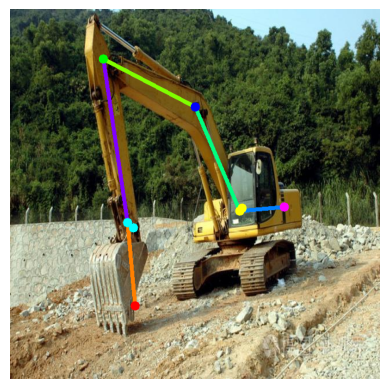

In [32]:
from mmdet.apis import init_detector, inference_detector
from mmpose.apis import MMPoseInferencer
from mmengine.structures import InstanceData
import mmcv
import cv2
from IPython.display import Image, display
import matplotlib.pyplot as plt

# --- Paths ---
# img = '/content/gdrive/MyDrive/Pytorch-Models/datasets/excavator/excavators.jpg'
# img = '/content/gdrive/MyDrive/Pytorch-Models/datasets/excavator/valid/Baidu_0044_jpeg_jpg.rf.96af2f9dfc6f80cbcb64c339ec193a68.jpg'
img = '/content/gdrive/MyDrive/Pytorch-Models/datasets/excavator/valid/Baidu_0090_jpeg_jpg.rf.62915ac8c1ba10ce731758b70660fece.jpg'
# img = '/content/gdrive/MyDrive/Pytorch-Models/datasets/excavator/train/ex2_mp4-0011_jpg.rf.c83b942611a7b6cf1da9d9a678641a65.jpg'

pose_config = '/content/gdrive/MyDrive/Pytorch-Models/mmpose/configs/body_2d_keypoint/dekr/coco/dekr_excavator.py'
pose_checkpoint = '/content/gdrive/MyDrive/Pytorch-Models/mmpose/work_dirs/dekr_excavator/best_coco_AP_epoch_46.pth'

pose_inferencer = MMPoseInferencer(pose2d=pose_config, pose2d_weights=pose_checkpoint)

# --- Step 2: Run Pose Inference ---
results_gen = pose_inferencer(
    img,
    return_vis=True,
    show=False,
    radius=8,       # Adjusts keypoint (point) size (default: 3)
    thickness=6,    # Adjusts link (line) thickness (default: 1)
    kpt_thr=0.001     # Optional: Threshold to filter visible points (default: 0.3)
)

# --- Step 3: Show ---
for r in results_gen:
    vis_img = r['visualization'][0]
    plt.imshow(vis_img)
    plt.axis('off')
    plt.show()

Loads checkpoint by local backend from path: /content/gdrive/MyDrive/Pytorch-Models/mmpose/work_dirs/dekr_excavator/best_coco_AP_epoch_46.pth
bbox: None
score: None
bbox: None
score: None
bbox: None
score: None


/usr/local/lib/python3.11/dist-packages/torch/nn/functional.py:4236: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(


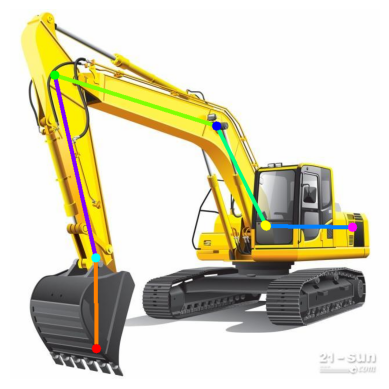

In [33]:
from mmdet.apis import init_detector, inference_detector
from mmpose.apis import MMPoseInferencer
from mmengine.structures import InstanceData
import mmcv
import cv2
from IPython.display import Image, display
import matplotlib.pyplot as plt

# --- Paths ---
# img = '/content/gdrive/MyDrive/Pytorch-Models/datasets/excavator/excavators.jpg'
img = '/content/gdrive/MyDrive/Pytorch-Models/datasets/excavator/valid/Baidu_0044_jpeg_jpg.rf.96af2f9dfc6f80cbcb64c339ec193a68.jpg'
# img = '/content/gdrive/MyDrive/Pytorch-Models/datasets/excavator/valid/Baidu_0090_jpeg_jpg.rf.62915ac8c1ba10ce731758b70660fece.jpg'
# img = '/content/gdrive/MyDrive/Pytorch-Models/datasets/excavator/train/ex2_mp4-0011_jpg.rf.c83b942611a7b6cf1da9d9a678641a65.jpg'

pose_config = '/content/gdrive/MyDrive/Pytorch-Models/mmpose/configs/body_2d_keypoint/dekr/coco/dekr_excavator.py'
pose_checkpoint = '/content/gdrive/MyDrive/Pytorch-Models/mmpose/work_dirs/dekr_excavator/best_coco_AP_epoch_46.pth'

pose_inferencer = MMPoseInferencer(pose2d=pose_config, pose2d_weights=pose_checkpoint)

# --- Step 2: Run Pose Inference ---
results_gen = pose_inferencer(
    img,
    return_vis=True,
    show=False,
    radius=8,       # Adjusts keypoint (point) size (default: 3)
    thickness=6,    # Adjusts link (line) thickness (default: 1)
    kpt_thr=0.001     # Optional: Threshold to filter visible points (default: 0.3)
)

for r in results_gen:
    # visualization
    vis_img = r['visualization'][0]
    # predictions
    preds = r['predictions'][0]

    for person in preds:
        keypoints = person['keypoints']
        bbox = person['bbox'] if 'bbox' in person else None
        score = person['bbox_score'] if 'bbox_score' in person else None
        print("bbox:", bbox)
        print("score:", score)
    plt.imshow(vis_img)
    plt.axis('off')
    plt.show()

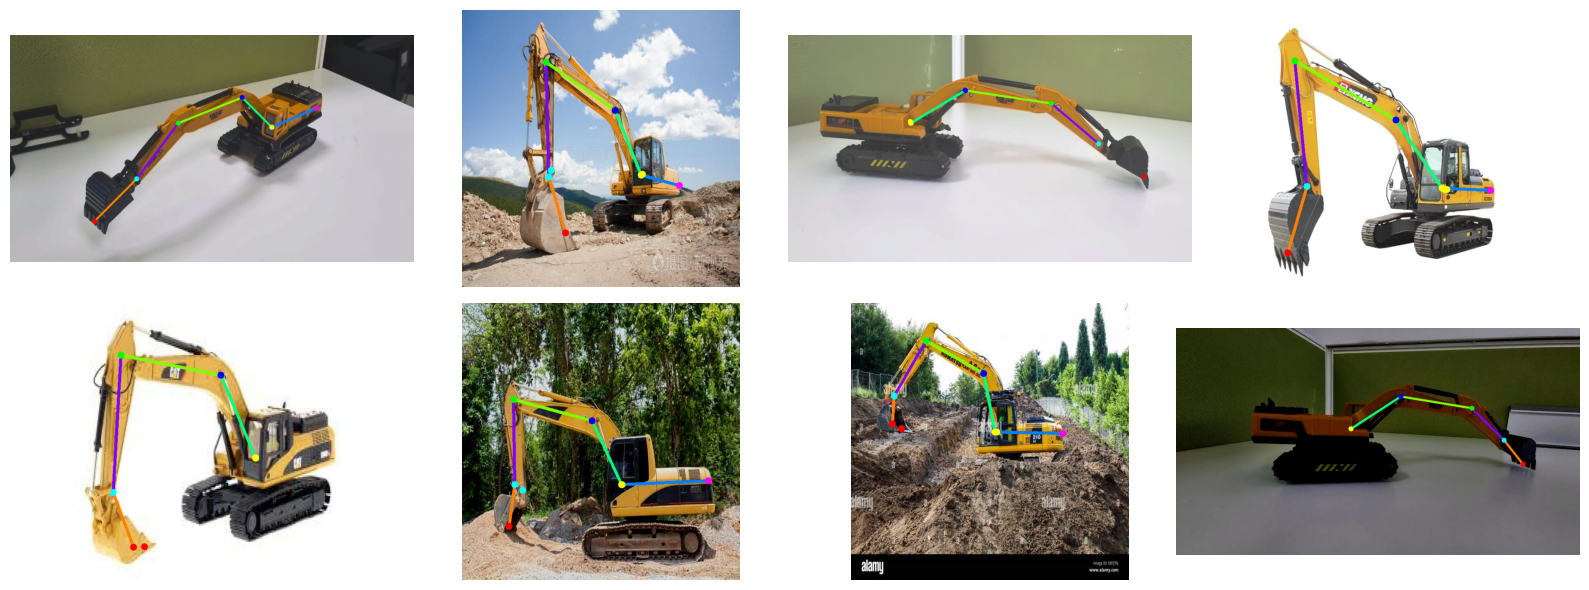

In [34]:
# ---------------- CONFIG ----------------
val_dir = "/content/gdrive/MyDrive/Pytorch-Models/datasets/excavator/train/"

import os
import random
import numpy as np

# visualization layout
N = 8
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 3 * rows))

for ii, image in enumerate(sample_imgs):
    plt.subplot(2, 4, ii+1)

    results_gen = pose_inferencer(
        image,
        return_vis=True,
        show=False,
        radius=8,       # Adjusts keypoint (point) size (default: 3)
        thickness=6,    # Adjusts link (line) thickness (default: 1)
        kpt_thr=0.001     # Optional: Threshold to filter visible points (default: 0.3)
    )

    for r in results_gen:
        vis_img = r['visualization'][0]

    plt.subplot(rows, cols, ii + 1)
    plt.imshow(vis_img)
    plt.axis("off")

plt.tight_layout()
plt.show()

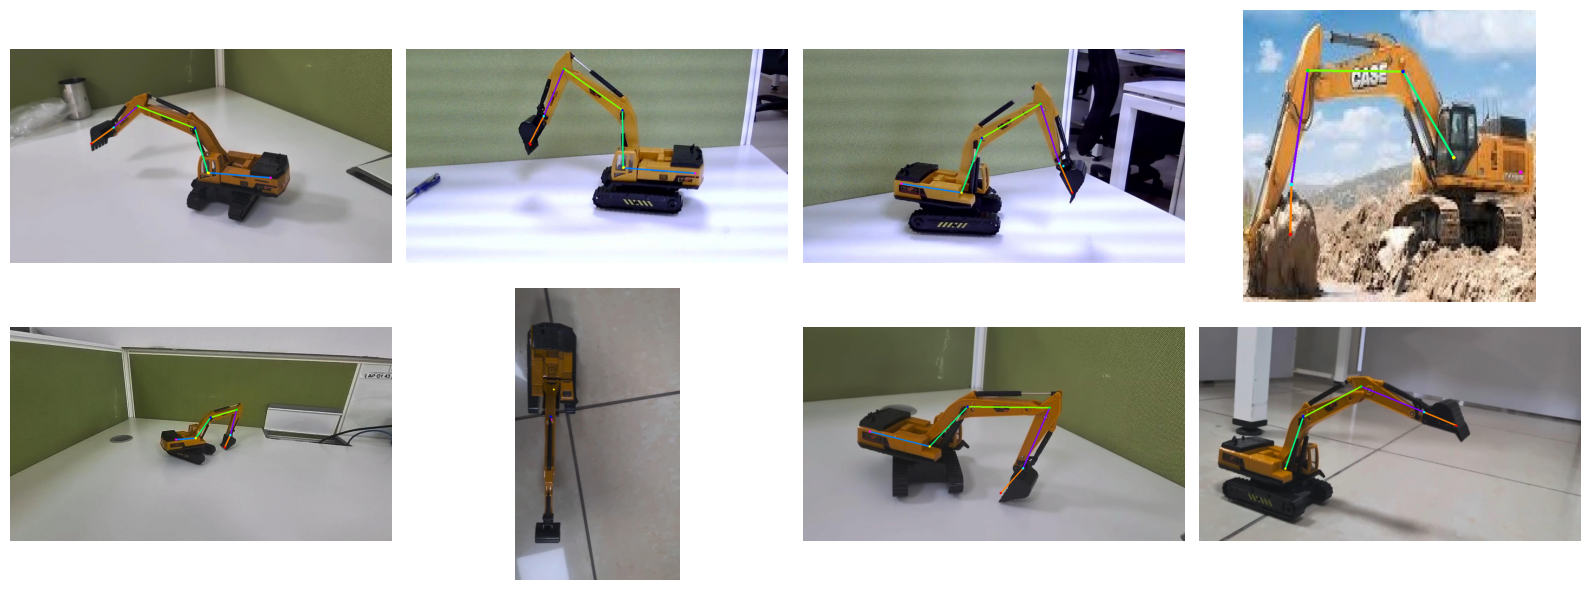

In [35]:
# ---------------- CONFIG ----------------
val_dir = "/content/gdrive/MyDrive/Pytorch-Models/datasets/excavator/valid/"

import os
import random
import numpy as np

# visualization layout
N = 8
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 3 * rows))

for ii, image in enumerate(sample_imgs):
    plt.subplot(2, 4, ii+1)

    results_gen = pose_inferencer(
        image,
        return_vis=True,
        show=False,
        radius=4,       # Adjusts keypoint (point) size (default: 3)
        thickness=3,    # Adjusts link (line) thickness (default: 1)
        kpt_thr=0.001     # Optional: Threshold to filter visible points (default: 0.3)
    )

    for r in results_gen:
        vis_img = r['visualization'][0]

    plt.subplot(rows, cols, ii + 1)
    plt.imshow(vis_img)
    plt.axis("off")

plt.tight_layout()
plt.show()

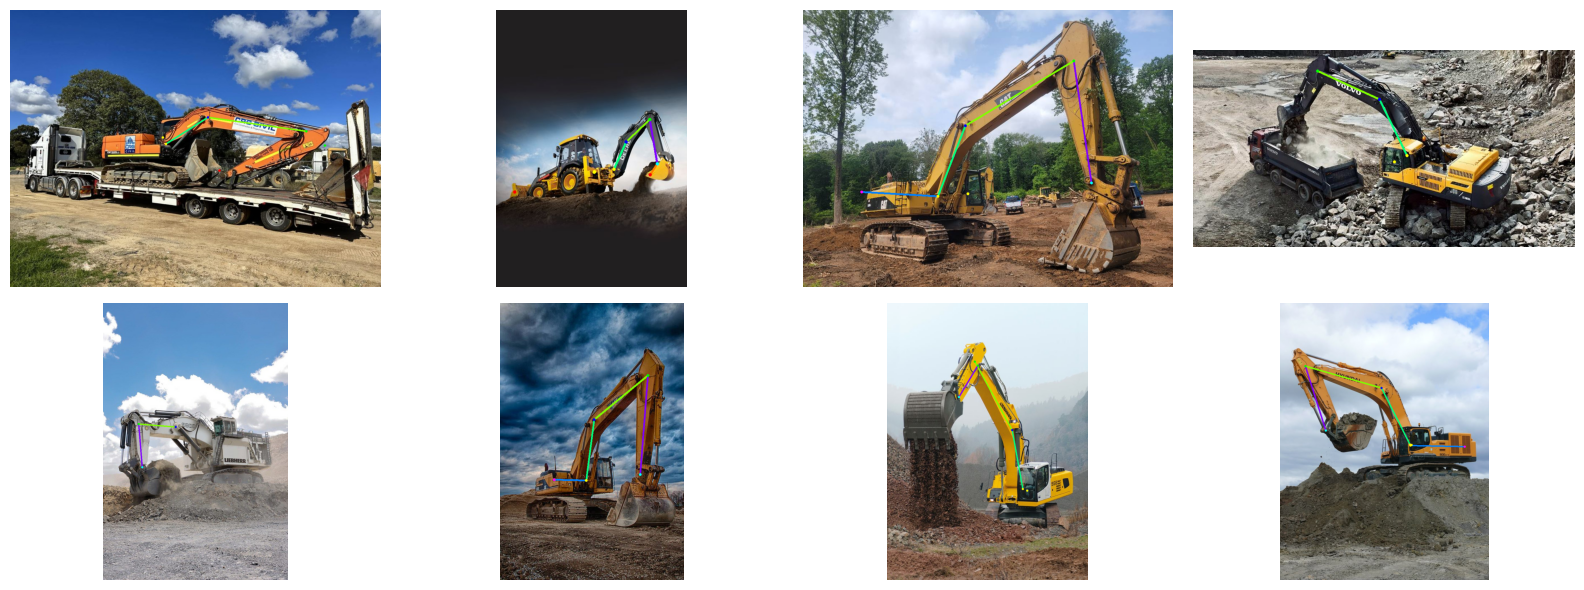

In [36]:
# ---------------- CONFIG ----------------
test_dir = '/content/gdrive/MyDrive/Pytorch-Models/datasets/excavator/excavators-test'

import os
import random
import numpy as np

# visualization layout
N = 8
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(test_dir, f)
            for f in os.listdir(test_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 3 * rows))

for ii, image in enumerate(sample_imgs):
    plt.subplot(2, 4, ii+1)

    results_gen = pose_inferencer(
        image,
        return_vis=True,
        show=False,
        radius=4,       # Adjusts keypoint (point) size (default: 3)
        thickness=3,    # Adjusts link (line) thickness (default: 1)
        kpt_thr=0.001     # Optional: Threshold to filter visible points (default: 0.3)
    )

    for r in results_gen:
        vis_img = r['visualization'][0]

    plt.subplot(rows, cols, ii + 1)
    plt.imshow(vis_img)
    plt.axis("off")

plt.tight_layout()
plt.show()